# DeepSentinel — TS-TCN Baseline Pipeline (Member 3)

**Project:** R26-IT-121 · **Author:** Pathirana P.K.V. (IT22237972) · **Supervisor:** Mrs. Anjalie Gamage

This notebook executes **Stages 1 & 2** of the TS-TCN Data Flow (TAF Table 4.1):

| Stage | Component | Deliverable |
|---|---|---|
| 1 | Feature Engineering (F1–F10) | `features.parquet` |
| 2 | Three-Baseline Evaluation (B0/B1/B2) | `baseline_metrics.json` |

**Strict adherence to the proposal:**

- **B0 — isFlaggedFraud rule:** `(type == TRANSFER) AND (amount > 200,000)` — TAF Table 3.3
- **B1 — Logistic Regression:** `liblinear`, `max_iter=1000`, `class_weight='balanced'` — TAF Table 3.3
- **B2 — MLP:** `Dense(64,relu) → Dropout(0.2) → Dense(32,relu) → Dropout(0.2) → Dense(1,sigmoid)`, `BinaryFocalCrossentropy(γ=2.0)` (Keras built-in) — TAF Table 3.3
- **Split:** time-based at `step ≤ 595` train / `step > 595` test — TAF §3.4
- **Features:** F1–F10 from TAF Table 3 — F6 weights derived from **training partition only** (FR1)
- **Functional requirements satisfied:** FR1, FR4, FR9 (partial), FR10 (partial)

Outputs are written to `outputs/` and copied to Google Drive at the end.


## Cell 0 — Environment Setup

Mount Google Drive, install dependencies, configure plotting.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 0 — Environment Setup, Imports, Plotting Theme
# ═══════════════════════════════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

import subprocess, sys
for p in ["kagglehub", "pyarrow", "fastparquet"]:
    subprocess.run([sys.executable, "-m", "pip", "install", p, "-q"], check=True)

import os, json, time, pickle, warnings, shutil, gc
from pathlib import Path
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, precision_score, recall_score, roc_auc_score, roc_curve,
    confusion_matrix, average_precision_score, precision_recall_curve,
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor":   "white",
    "axes.facecolor":     "#F9F9F9",
    "axes.edgecolor":     "#333333",
    "axes.labelcolor":    "#222222",
    "xtick.color":        "#333333",
    "ytick.color":        "#333333",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "font.family":        "DejaVu Sans",
    "font.size":          11,
    "axes.grid":          True,
    "grid.color":         "#E0E0E0",
    "grid.linestyle":     "--",
    "grid.alpha":         0.6,
})

DS_BLUE   = "#1A5276"
DS_RED    = "#C0392B"
DS_GREEN  = "#1E8449"
DS_ORANGE = "#D35400"
DS_PURPLE = "#6C3483"
DS_GREY   = "#7F8C8D"

OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)

print("✅ Environment ready")
print(f"   TensorFlow : {tf.__version__}")
print(f"   GPU        : {tf.config.list_physical_devices('GPU') or 'NONE — running on CPU'}")
print(f"   Output dir : {OUT_DIR.resolve()}")


Mounted at /content/drive
✅ Environment ready
   TensorFlow : 2.20.0
   GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
   Output dir : /content/outputs


## Cell 1 — Load PaySim Dataset

Download from KaggleHub. Per TAF §1.1: **6,362,620** transactions, **743** simulation hours, **8,213** fraud events.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 1 — Load PaySim
# ═══════════════════════════════════════════════════════════════════════════════
import kagglehub

print("📥 Downloading PaySim from KaggleHub …")
path = kagglehub.dataset_download("ealaxi/paysim1")
csv_files = list(Path(path).glob("*.csv"))
CSV_PATH = csv_files[0]
print(f"   File: {CSV_PATH.name}")

t0 = time.time()
df = pd.read_csv(CSV_PATH)
print(f"📦 Loaded {len(df):,} rows in {time.time()-t0:.1f}s")

assert len(df) == 6_362_620, f"Row count mismatch: {len(df)}"
assert df["step"].max() == 743, f"Step range mismatch: max={df['step'].max()}"
assert df["isFraud"].sum() == 8_213, f"Fraud count mismatch: {df['isFraud'].sum()}"

print(f"✅ Integrity verified: {len(df):,} rows · {df['step'].max()} steps · "
      f"{df['isFraud'].sum():,} fraud events")
df.head(3)


📥 Downloading PaySim from KaggleHub …
Using Colab cache for faster access to the 'paysim1' dataset.
   File: PS_20174392719_1491204439457_log.csv
📦 Loaded 6,362,620 rows in 25.6s
✅ Integrity verified: 6,362,620 rows · 743 steps · 8,213 fraud events


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0


## Cell 2 — Exploratory Data Analysis

Multi-panel EDA covering the four observations that motivate the TS-TCN design:

1. **Class imbalance** (1 : 773) → motivates focal loss
2. **Fraud temporal distribution** → validates time-based split at step 595
3. **Fraud type breakdown** → only `TRANSFER` and `CASH_OUT` produce fraud (motivates F6)
4. **`isFlaggedFraud` rule failure** → motivates B0 baseline and TS-TCN
5. **Amount distribution** (fraud vs legit) → motivates F1 and F2

──────────────────────────────────────────────────────────────────────
  PaySim Dataset Snapshot
──────────────────────────────────────────────────────────────────────
  Total transactions          :    6,362,620
  Fraud transactions          :        8,213  (0.1291%)
  Class imbalance (legit:fraud): 1 : 774
  isFlaggedFraud raised       :           16 (global)
  Fraud caught by isFlaggedFraud:          16 of 8,213 → 0.195% recall
──────────────────────────────────────────────────────────────────────


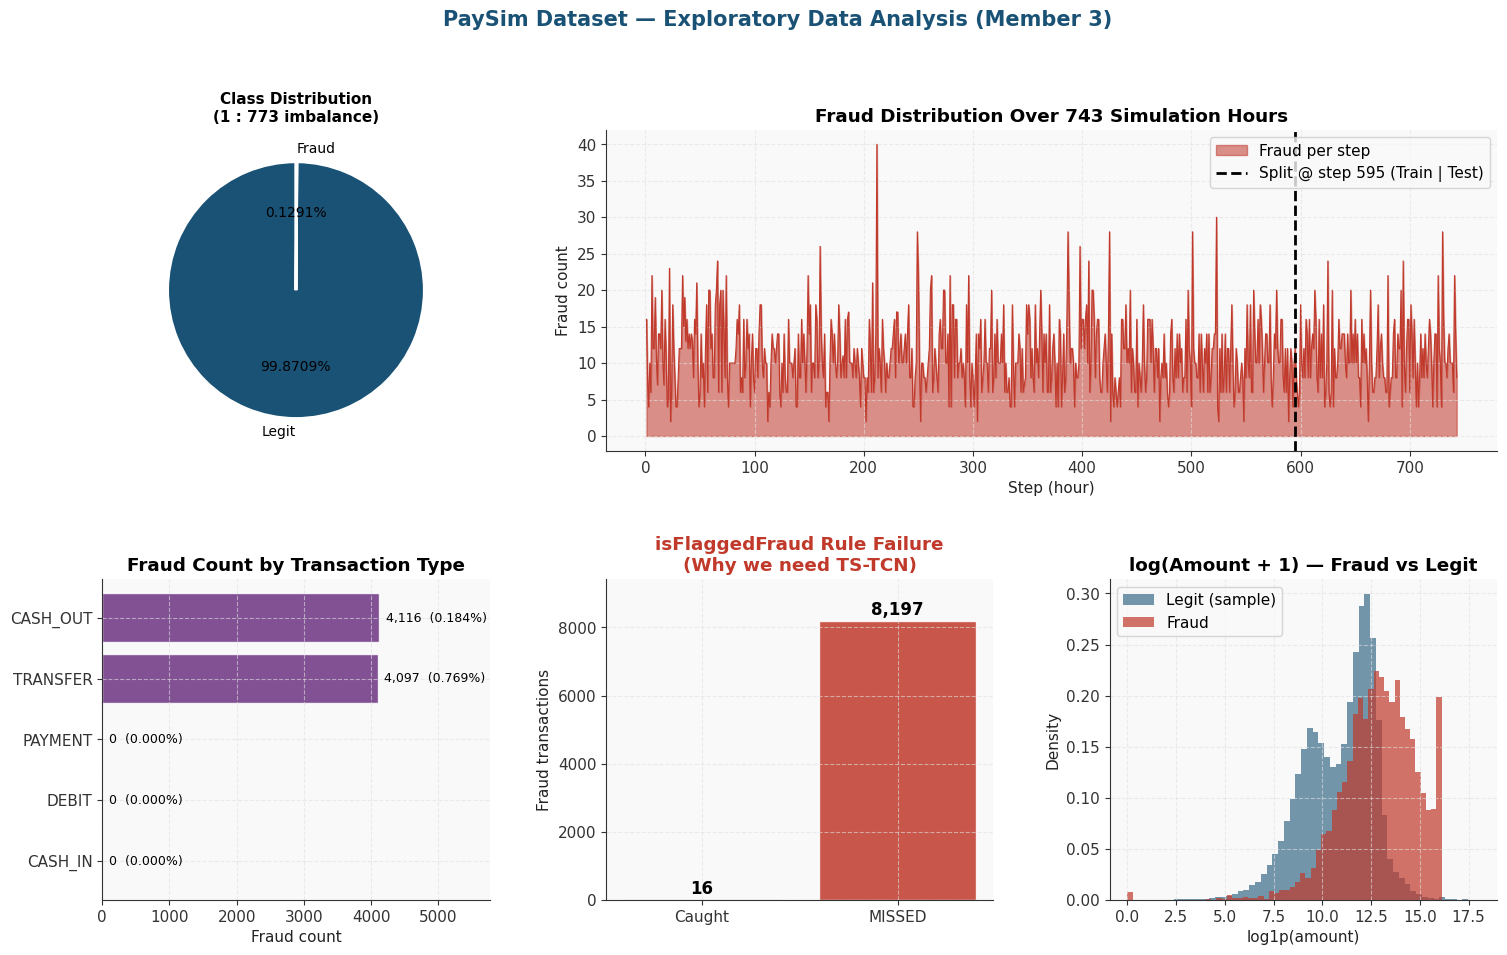

💾 Saved: outputs/01_eda_overview.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 2 — EDA Dashboard
# ═══════════════════════════════════════════════════════════════════════════════
fraud_count   = int(df["isFraud"].sum())
flagged_count = int(df["isFlaggedFraud"].sum())
total         = len(df)
imbalance     = (total - fraud_count) / fraud_count
b0_caught_global = int(((df["isFlaggedFraud"] == 1) & (df["isFraud"] == 1)).sum())

print("─" * 70)
print("  PaySim Dataset Snapshot")
print("─" * 70)
print(f"  Total transactions          : {total:>12,}")
print(f"  Fraud transactions          : {fraud_count:>12,}  ({fraud_count/total*100:.4f}%)")
print(f"  Class imbalance (legit:fraud): 1 : {imbalance:.0f}")
print(f"  isFlaggedFraud raised       : {flagged_count:>12,} (global)")
print(f"  Fraud caught by isFlaggedFraud: {b0_caught_global:>11,} of {fraud_count:,} → "
      f"{b0_caught_global/fraud_count*100:.3f}% recall")
print("─" * 70)

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.3)
fig.suptitle("PaySim Dataset — Exploratory Data Analysis (Member 3)",
             fontsize=15, fontweight="bold", color=DS_BLUE, y=1.00)

ax1 = fig.add_subplot(gs[0, 0])
ax1.pie([total - fraud_count, fraud_count],
        labels=["Legit", "Fraud"], colors=[DS_BLUE, DS_RED],
        autopct="%1.4f%%", startangle=90,
        wedgeprops={"edgecolor": "white", "linewidth": 2},
        textprops={"fontsize": 10})
ax1.set_title("Class Distribution\n(1 : 773 imbalance)", fontweight="bold", fontsize=11)

ax2 = fig.add_subplot(gs[0, 1:])
fraud_by_step = df[df["isFraud"] == 1].groupby("step").size()
ax2.fill_between(fraud_by_step.index, fraud_by_step.values, color=DS_RED, alpha=0.55, label="Fraud per step")
ax2.plot(fraud_by_step.index, fraud_by_step.values, color=DS_RED, linewidth=0.8)
ax2.axvline(595, color="black", linestyle="--", linewidth=2, label="Split @ step 595 (Train | Test)")
ax2.set_title("Fraud Distribution Over 743 Simulation Hours", fontweight="bold")
ax2.set_xlabel("Step (hour)"); ax2.set_ylabel("Fraud count")
ax2.legend(loc="upper right")

ax3 = fig.add_subplot(gs[1, 0])
type_fraud  = df.groupby("type")["isFraud"].sum().sort_values(ascending=True)
type_total  = df.groupby("type").size().reindex(type_fraud.index)
type_rate   = (type_fraud / type_total * 100).round(3)
bars = ax3.barh(type_fraud.index, type_fraud.values, color=DS_PURPLE, alpha=0.85, edgecolor="white")
for bar, rate in zip(bars, type_rate.values):
    w = bar.get_width()
    ax3.text(w + 100, bar.get_y() + bar.get_height()/2,
             f"{int(w):,}  ({rate:.3f}%)", va="center", fontsize=9)
ax3.set_title("Fraud Count by Transaction Type", fontweight="bold")
ax3.set_xlabel("Fraud count")
ax3.set_xlim(0, type_fraud.max() * 1.4)

ax4 = fig.add_subplot(gs[1, 1])
caught = b0_caught_global; missed = fraud_count - caught
bars = ax4.bar(["Caught", "MISSED"], [caught, missed],
               color=[DS_GREEN, DS_RED], alpha=0.85, edgecolor="white")
for bar, v in zip(bars, [caught, missed]):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(50, missed*0.02),
             f"{v:,}", ha="center", fontsize=12, fontweight="bold")
ax4.set_title("isFlaggedFraud Rule Failure\n(Why we need TS-TCN)",
              fontweight="bold", color=DS_RED)
ax4.set_ylabel("Fraud transactions")
ax4.set_ylim(0, missed * 1.15)

ax5 = fig.add_subplot(gs[1, 2])
sample_legit = df[df["isFraud"] == 0].sample(min(200_000, total - fraud_count), random_state=SEED)
ax5.hist(np.log1p(sample_legit["amount"]), bins=60, alpha=0.6, color=DS_BLUE, label="Legit (sample)", density=True)
ax5.hist(np.log1p(df.loc[df["isFraud"] == 1, "amount"]), bins=60,
         alpha=0.7, color=DS_RED, label="Fraud", density=True)
ax5.set_title("log(Amount + 1) — Fraud vs Legit", fontweight="bold")
ax5.set_xlabel("log1p(amount)"); ax5.set_ylabel("Density")
ax5.legend()

plt.tight_layout()
plt.savefig(OUT_DIR / "01_eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"💾 Saved: {OUT_DIR}/01_eda_overview.png")


## Cell 3 — Feature Engineering (F1–F10)

Implements the **exact PaySim formulas from TAF Table 3**, with no leakage:

| ID | Feature | Formula |
|---|---|---|
| F1 | drain_ratio | `min(amount / (oldbalanceOrg + 1), 1.0)` |
| F2 | log_amount | `log1p(amount)` |
| F3 | post_transfer_ratio | `newbalanceOrig / (oldbalanceOrg + 1)` |
| F4 | dest_was_empty | `float(oldbalanceDest == 0)` |
| F5 | dest_enrichment | `min((newbalDest − oldbalDest) / (amount + 1), 2.0)` |
| F6 | type_risk_weight | `fraud_count_type / total_fraud` (**train only**) |
| F7 | inv_dest_ratio | `log1p(oldbalanceDest) / (log1p(newbalanceDest) + 1)` |
| F8 | amt_to_orig | `log1p(amount) / (log1p(oldbalanceOrg) + 1)` |
| F9 | hour_of_day | `((step − 1) % 24) / 23.0` |
| F10 | day_of_week | `(((step − 1) // 24) % 7) / 6.0` |

**FR1 compliance:** F6 is computed using only `step ≤ 595` (training partition).  
**Composite ID:** `nameOrig_step` is created for cross-component referencing (Member 4).

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 3 — Feature Engineering F1–F10 (TAF Table 3, no leakage)
# ═══════════════════════════════════════════════════════════════════════════════
SPLIT_STEP = 595

train_mask = df["step"] <= SPLIT_STEP
total_fraud_train  = int(df.loc[train_mask, "isFraud"].sum())
fraud_by_type_train = df.loc[train_mask & (df["isFraud"] == 1)].groupby("type").size()
TYPE_RISK_WEIGHTS  = (fraud_by_type_train / total_fraud_train).to_dict()
for t in ["CASH_IN", "CASH_OUT", "DEBIT", "PAYMENT", "TRANSFER"]:
    TYPE_RISK_WEIGHTS.setdefault(t, 0.0)

print("F6 — Type Risk Weights (derived from TRAIN partition, step ≤ 595):")
for k, v in sorted(TYPE_RISK_WEIGHTS.items(), key=lambda x: -x[1]):
    print(f"   {k:<10s} : {v:.4f}")

with open(OUT_DIR / "type_risk_weights.json", "w") as f:
    json.dump(TYPE_RISK_WEIGHTS, f, indent=2)

print("\nComputing features F1–F10 over 6.36M rows …")
t0 = time.time()
eps = 1.0
df_feat = df.copy()

df_feat["drain_ratio"]         = np.minimum(df_feat["amount"] / (df_feat["oldbalanceOrg"] + eps), 1.0)
df_feat["log_amount"]          = np.log1p(df_feat["amount"])
df_feat["post_transfer_ratio"] = df_feat["newbalanceOrig"] / (df_feat["oldbalanceOrg"] + eps)
df_feat["dest_was_empty"]      = (df_feat["oldbalanceDest"] == 0).astype(np.float32)
df_feat["dest_enrichment"]     = np.minimum(
    (df_feat["newbalanceDest"] - df_feat["oldbalanceDest"]) / (df_feat["amount"] + eps), 2.0
)
df_feat["type_risk_weight"]    = df_feat["type"].map(TYPE_RISK_WEIGHTS).fillna(0.0).astype(np.float32)
df_feat["inv_dest_ratio"]      = np.log1p(df_feat["oldbalanceDest"]) / (np.log1p(df_feat["newbalanceDest"]) + eps)
df_feat["amt_to_orig"]         = np.log1p(df_feat["amount"])      / (np.log1p(df_feat["oldbalanceOrg"]) + eps)
df_feat["hour_of_day"]         = ((df_feat["step"] - 1) % 24) / 23.0
df_feat["day_of_week"]         = (((df_feat["step"] - 1) // 24) % 7) / 6.0

df_feat["composite_id"] = df_feat["nameOrig"].astype(str) + "_" + df_feat["step"].astype(str)

FEATURE_NAMES = [
    "drain_ratio", "log_amount", "post_transfer_ratio", "dest_was_empty",
    "dest_enrichment", "type_risk_weight", "inv_dest_ratio",
    "amt_to_orig", "hour_of_day", "day_of_week",
]

nan_count = int(df_feat[FEATURE_NAMES].isna().sum().sum())
inf_count = int(np.isinf(df_feat[FEATURE_NAMES].values).sum())
assert nan_count == 0, f"NaN values present: {nan_count}"
assert inf_count == 0, f"Inf values present: {inf_count}"

print(f"✅ Features computed in {time.time()-t0:.1f}s · NaN={nan_count} · Inf={inf_count}")

print("\nFeature ranges:")
desc = df_feat[FEATURE_NAMES].describe().T[["min", "mean", "max", "std"]].round(4)
print(desc.to_string())


F6 — Type Risk Weights (derived from TRAIN partition, step ≤ 595):
   CASH_OUT   : 0.5014
   TRANSFER   : 0.4986
   CASH_IN    : 0.0000
   DEBIT      : 0.0000
   PAYMENT    : 0.0000

Computing features F1–F10 over 6.36M rows …
✅ Features computed in 14.2s · NaN=0 · Inf=0

Feature ranges:
                            min      mean          max        std
drain_ratio              0.0000    0.7157       1.0000     0.4095
log_amount               0.0000   10.8409      18.3421     1.8145
post_transfer_ratio      0.0000  385.4081  813160.8300  9987.2834
dest_was_empty           0.0000    0.4250       1.0000     0.4907
dest_enrichment     -51358.9602    0.1478       2.0000    40.7008
type_risk_weight         0.0000    0.2181       0.5014     0.2564
inv_dest_ratio           0.0000    0.7197      16.3851     1.4966
amt_to_orig              0.0000    4.2162      18.3421     4.7760
hour_of_day              0.0000    0.6344       1.0000     0.1783
day_of_week              0.0000    0.4130       1.0

## Cell 4 — Persist `features.parquet`

Save for downstream stages (TS-TCN window construction).

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 4 — Save features.parquet (Stage 1 deliverable)
# ═══════════════════════════════════════════════════════════════════════════════
PARQUET_PATH = "features.parquet"

cols_to_save = ["step", "type", "amount", "nameOrig", "composite_id",
                "isFraud", "isFlaggedFraud"] + FEATURE_NAMES
t0 = time.time()
df_feat[cols_to_save].to_parquet(PARQUET_PATH, index=False, compression="snappy")
size_mb = os.path.getsize(PARQUET_PATH) / 1024**2
print(f"✅ {PARQUET_PATH}: {size_mb:.1f} MB · saved in {time.time()-t0:.1f}s")

del df; gc.collect()
print("✅ Stage 1 complete")


✅ features.parquet: 376.0 MB · saved in 6.2s
✅ Stage 1 complete


## Cell 5 — Feature Separation Diagnostics

Validates that the engineered features carry fraud signal. The `drain_ratio` (F1) plot reproduces **TAF Figure A3** — overlapping fraud-vs-legit histogram showing near-perfect separation at `drain_ratio → 1.0`.

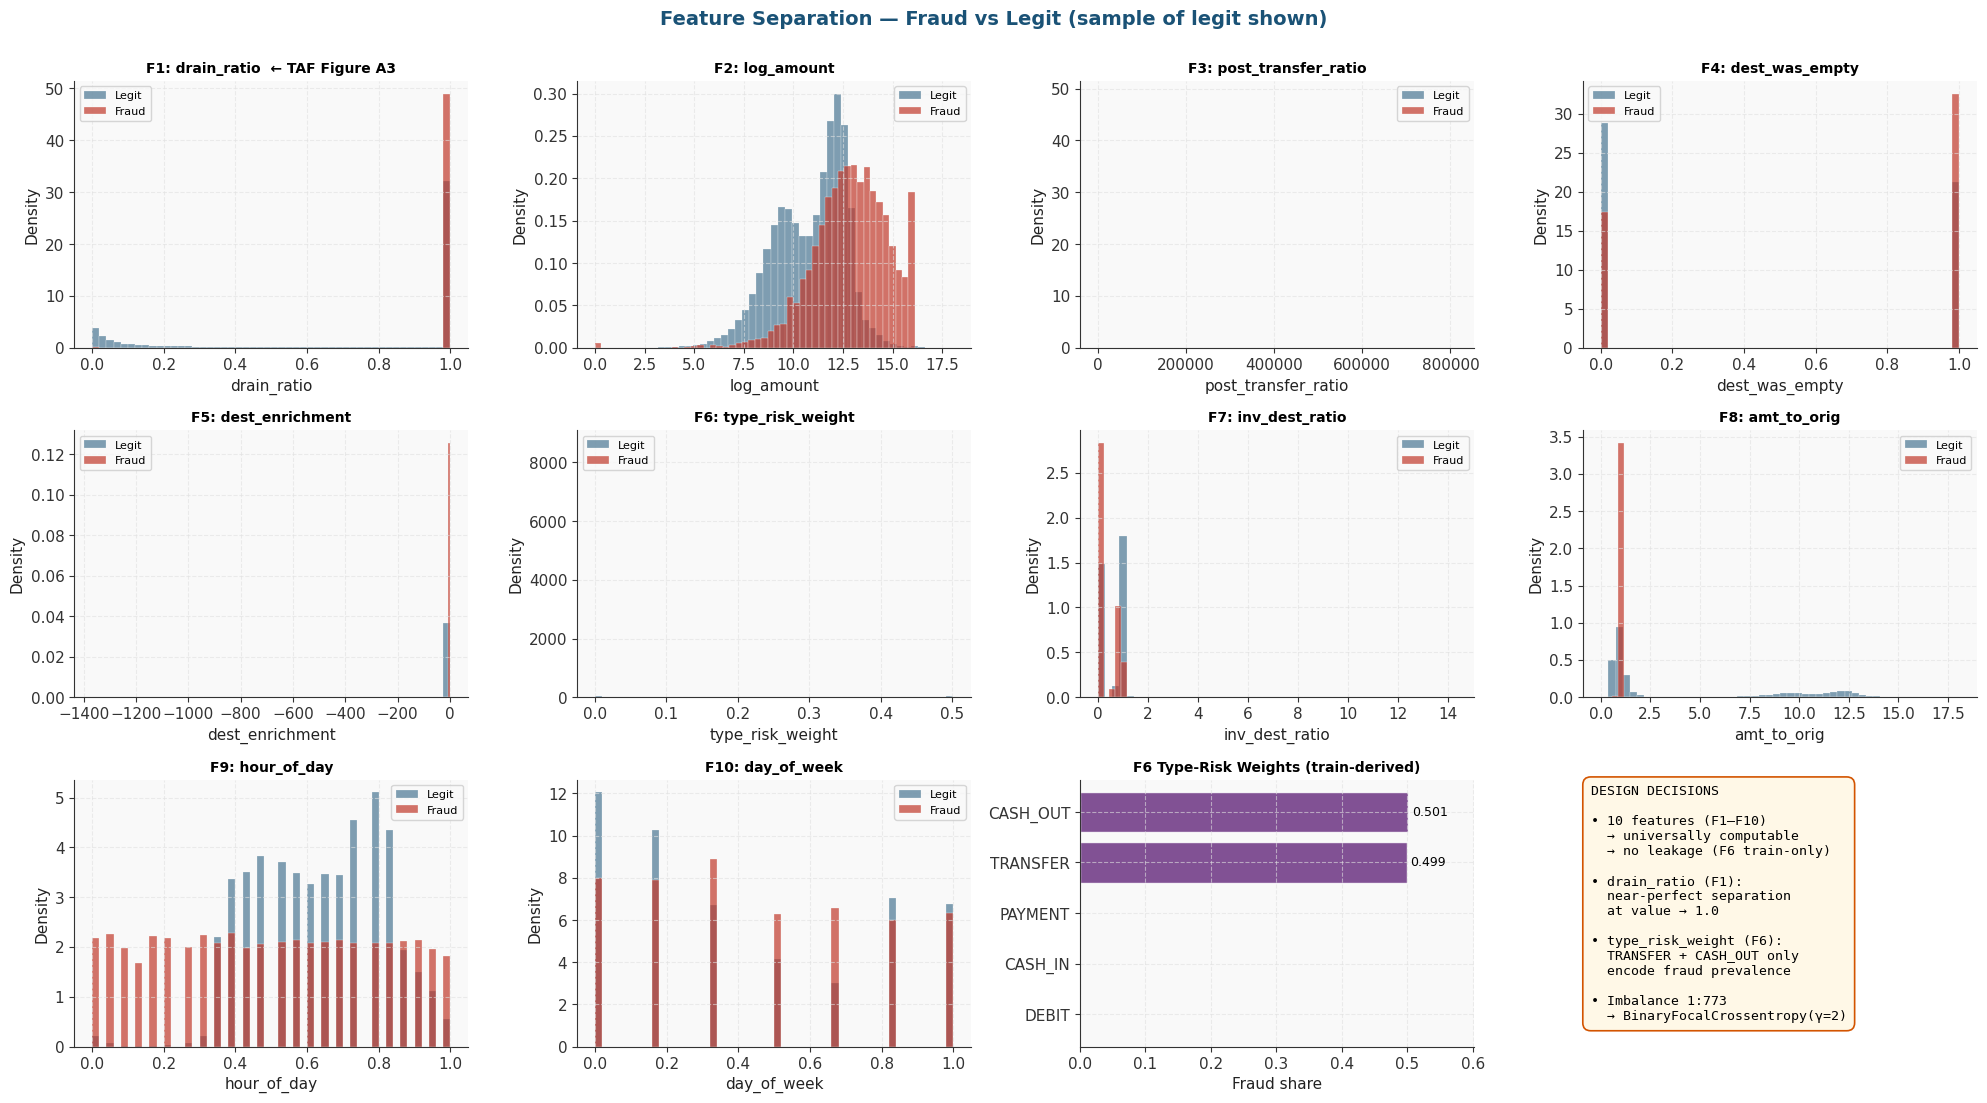

💾 Saved: outputs/02_feature_distributions.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 5 — Feature distributions, fraud vs legit
# ═══════════════════════════════════════════════════════════════════════════════
SAMPLE_N = 300_000
fraud_df_plot = df_feat[df_feat["isFraud"] == 1]
legit_sample  = df_feat[df_feat["isFraud"] == 0].sample(SAMPLE_N, random_state=SEED)

fig, axes = plt.subplots(3, 4, figsize=(20, 11))
fig.suptitle("Feature Separation — Fraud vs Legit (sample of legit shown)",
             fontsize=14, fontweight="bold", color=DS_BLUE, y=1.00)
axes = axes.flatten()

for i, feat in enumerate(FEATURE_NAMES):
    ax = axes[i]
    ax.hist(legit_sample[feat], bins=50, color=DS_BLUE, alpha=0.55,
            density=True, label="Legit", edgecolor="white", linewidth=0.3)
    ax.hist(fraud_df_plot[feat], bins=50, color=DS_RED, alpha=0.7,
            density=True, label="Fraud", edgecolor="white", linewidth=0.3)
    title = f"F{i+1}: {feat}"
    if feat == "drain_ratio":
        title += "  ← TAF Figure A3"
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.legend(fontsize=8, loc="best")
    ax.set_xlabel(feat); ax.set_ylabel("Density")

for ax in axes[10:]:
    ax.set_visible(False)

ax_extra = fig.add_subplot(3, 4, 11)
type_w = pd.Series(TYPE_RISK_WEIGHTS).sort_values(ascending=True)
bars = ax_extra.barh(type_w.index, type_w.values, color=DS_PURPLE, alpha=0.85, edgecolor="white")
for bar in bars:
    w = bar.get_width()
    if w > 0:
        ax_extra.text(w + 0.005, bar.get_y() + bar.get_height()/2,
                      f"{w:.3f}", va="center", fontsize=9)
ax_extra.set_title("F6 Type-Risk Weights (train-derived)", fontsize=10, fontweight="bold")
ax_extra.set_xlabel("Fraud share")
ax_extra.set_xlim(0, max(type_w.max() * 1.2, 0.1))

ax_box = fig.add_subplot(3, 4, 12)
ax_box.axis("off")
summary = (
    "DESIGN DECISIONS\n\n"
    "• 10 features (F1–F10)\n"
    "  → universally computable\n"
    "  → no leakage (F6 train-only)\n\n"
    "• drain_ratio (F1):\n"
    "  near-perfect separation\n"
    "  at value → 1.0\n\n"
    "• type_risk_weight (F6):\n"
    "  TRANSFER + CASH_OUT only\n"
    "  encode fraud prevalence\n\n"
    "• Imbalance 1:773\n"
    "  → BinaryFocalCrossentropy(γ=2)"
)
ax_box.text(0.02, 0.98, summary, transform=ax_box.transAxes,
            fontsize=9.5, va="top", ha="left", family="monospace",
            bbox=dict(boxstyle="round,pad=0.6", facecolor="#FFF8E7",
                      edgecolor=DS_ORANGE, linewidth=1.2))

plt.tight_layout()
plt.savefig(OUT_DIR / "02_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

del df_feat, legit_sample, fraud_df_plot
gc.collect()
print(f"💾 Saved: {OUT_DIR}/02_feature_distributions.png")


## Cell 6 — Time-Based Split & Scaler Fit

Per TAF §3.4: train on `step ≤ 595`, test on `step > 595`. The `StandardScaler` is **fit on training data only** to prevent leakage.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 6 — Train/Test Split, StandardScaler fit (no leakage)
# ═══════════════════════════════════════════════════════════════════════════════
needed_cols = ["step", "type", "amount", "isFraud", "isFlaggedFraud"] + FEATURE_NAMES
df_full = pd.read_parquet(PARQUET_PATH, columns=needed_cols)

train_df = df_full[df_full["step"] <= SPLIT_STEP]
test_df  = df_full[df_full["step"] >  SPLIT_STEP]

print(f"Train rows : {len(train_df):>10,}  · fraud {int(train_df['isFraud'].sum()):>6,}")
print(f"Test  rows : {len(test_df):>10,}  · fraud {int(test_df['isFraud'].sum()):>6,}")

assert int(test_df["isFraud"].sum()) == 1_642, \
    f"Test fraud count != 1,642 (got {int(test_df['isFraud'].sum())})"
print("✅ Test fraud count = 1,642 (matches TAF §3.9)")

scaler = StandardScaler()
X_train = train_df[FEATURE_NAMES].values.astype(np.float32)
y_train = train_df["isFraud"].values.astype(np.float32)
X_test  = test_df[FEATURE_NAMES].values.astype(np.float32)
y_test  = test_df["isFraud"].values.astype(np.float32)

scaler.fit(X_train)
X_train_sc = scaler.transform(X_train)
X_test_sc  = scaler.transform(X_test)

with open(OUT_DIR / "scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print(f"✅ Scaler fit on TRAIN only · saved → {OUT_DIR}/scaler.pkl")

np.save(OUT_DIR / "y_test.npy", y_test)
print(f"✅ y_test.npy saved ({len(y_test):,} samples)")


Train rows :  6,244,474  · fraud  6,571
Test  rows :    118,146  · fraud  1,642
✅ Test fraud count = 1,642 (matches TAF §3.9)
✅ Scaler fit on TRAIN only · saved → outputs/scaler.pkl
✅ y_test.npy saved (118,146 samples)


## Cell 7 — Baseline 0: `isFlaggedFraud` Rule

**TAF Table 3.3 spec:** `(type == "TRANSFER") AND (amount > 200,000)` — published PaySim baseline, no ML.

This is implemented from raw `type` and `amount` columns, **not** from the precomputed `isFlaggedFraud` field.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 7 — Baseline 0: Published PaySim rule (TAF Table 3.3)
# Rule: type == "TRANSFER" AND amount > 200,000
# ═══════════════════════════════════════════════════════════════════════════════
y_b0_pred = ((test_df["type"] == "TRANSFER") &
             (test_df["amount"] > 200_000)).astype(np.int32).values
y_b0_prob = y_b0_pred.astype(np.float32)

b0_metrics = {
    "model":     "B0 — isFlaggedFraud rule (TRANSFER & amount>200K)",
    "uses_sequence": False,
    "f1":        float(f1_score(y_test, y_b0_pred, zero_division=0)),
    "precision": float(precision_score(y_test, y_b0_pred, zero_division=0)),
    "recall":    float(recall_score(y_test, y_b0_pred, zero_division=0)),
    "auc_roc":   float(roc_auc_score(y_test, y_b0_prob)),
    "predicted_fraud_count": int(y_b0_pred.sum()),
    "true_fraud_count":      int(y_test.sum()),
    "true_positives":        int(((y_b0_pred == 1) & (y_test == 1)).sum()),
}

print("─" * 60)
print(f"  B0 — Rule baseline")
print("─" * 60)
for k in ["f1", "precision", "recall", "auc_roc"]:
    print(f"   {k:<12s}: {b0_metrics[k]:.4f}")
print(f"   Predicted fraud : {b0_metrics['predicted_fraud_count']:,}")
print(f"   True positives  : {b0_metrics['true_positives']:,} of "
      f"{b0_metrics['true_fraud_count']:,}")
print("─" * 60)

np.save(OUT_DIR / "b0_probs.npy", y_b0_prob)


────────────────────────────────────────────────────────────
  B0 — Rule baseline
────────────────────────────────────────────────────────────
   f1          : 0.1141
   precision   : 0.0686
   recall      : 0.3380
   auc_roc     : 0.6367
   Predicted fraud : 8,086
   True positives  : 555 of 1,642
────────────────────────────────────────────────────────────


## Cell 8 — Baseline 1: Logistic Regression

**TAF Table 3.3 spec (exact):** `solver="liblinear"`, `max_iter=1000`, `class_weight="balanced"`. Tests linear separability.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 8 — Baseline 1: Logistic Regression (TAF Table 3.3 EXACT)
# ═══════════════════════════════════════════════════════════════════════════════
print("Training Logistic Regression …")
t1 = time.time()

lr = LogisticRegression(
    solver="liblinear",
    max_iter=1000,
    class_weight="balanced",
    random_state=SEED,
)
lr.fit(X_train_sc, y_train)
elapsed_b1 = time.time() - t1

y_b1_prob = lr.predict_proba(X_test_sc)[:, 1]
y_b1_pred = lr.predict(X_test_sc).astype(np.int32)

b1_metrics = {
    "model":     "B1 — Logistic Regression",
    "uses_sequence": False,
    "f1":        float(f1_score(y_test, y_b1_pred)),
    "precision": float(precision_score(y_test, y_b1_pred)),
    "recall":    float(recall_score(y_test, y_b1_pred)),
    "auc_roc":   float(roc_auc_score(y_test, y_b1_prob)),
    "training_seconds": round(elapsed_b1, 2),
    "predicted_fraud_count": int(y_b1_pred.sum()),
    "true_positives":        int(((y_b1_pred == 1) & (y_test == 1)).sum()),
}

print("─" * 60)
print(f"  B1 — Logistic Regression  ({elapsed_b1:.1f}s)")
print("─" * 60)
for k in ["f1", "precision", "recall", "auc_roc"]:
    print(f"   {k:<12s}: {b1_metrics[k]:.4f}")
print("─" * 60)

np.save(OUT_DIR / "b1_probs.npy", y_b1_prob)
with open(OUT_DIR / "lr_model.pkl", "wb") as f:
    pickle.dump(lr, f)
print("✅ B1 saved · lr_model.pkl, b1_probs.npy")


Training Logistic Regression …
────────────────────────────────────────────────────────────
  B1 — Logistic Regression  (44.8s)
────────────────────────────────────────────────────────────
   f1          : 0.1223
   precision   : 0.0653
   recall      : 0.9689
   auc_roc     : 0.9583
────────────────────────────────────────────────────────────
✅ B1 saved · lr_model.pkl, b1_probs.npy


## Cell 9 — Baseline 2: MLP (Non-Linear, No Sequence)

**TAF Table 3.3 spec (exact):**
- Architecture: `Dense(64,relu) → Dropout(0.2) → Dense(32,relu) → Dropout(0.2) → Dense(1,sigmoid)`
- Loss: `BinaryFocalCrossentropy(γ=2.0)` (Keras built-in)
- Optimizer: `Adam(lr=0.001)`, batch=4096, EarlyStopping on `val_recall` patience=5

The performance gap between this MLP and the TS-TCN (same features, but with W=32 sequence) isolates the contribution of temporal context (TAF §3.6 final paragraph).

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 9 — Baseline 2: MLP with Keras BinaryFocalCrossentropy(γ=2.0)
# TAF Table 3.3 EXACT spec
# ═══════════════════════════════════════════════════════════════════════════════
keras.backend.clear_session()
tf.random.set_seed(SEED); np.random.seed(SEED)

inputs  = keras.Input(shape=(len(FEATURE_NAMES),), name="features")
x       = layers.Dense(64, activation="relu", name="dense_64")(inputs)
x       = layers.Dropout(0.2, name="dropout_1")(x)
x       = layers.Dense(32, activation="relu", name="dense_32")(x)
x       = layers.Dropout(0.2, name="dropout_2")(x)
outputs = layers.Dense(1, activation="sigmoid", name="fraud_prob")(x)

mlp = Model(inputs, outputs, name="B2_MLP_NoSequence")

mlp.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.BinaryFocalCrossentropy(gamma=2.0, from_logits=False),
    metrics=[
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc"),
    ],
)
mlp.summary()

BATCH_SIZE = 4096
train_ds = (tf.data.Dataset.from_tensor_slices((X_train_sc, y_train))
            .shuffle(10_000, seed=SEED).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))
test_ds  = (tf.data.Dataset.from_tensor_slices((X_test_sc, y_test))
            .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_recall", mode="max", patience=5,
        restore_best_weights=True, verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=str(OUT_DIR / "best_mlp.keras"),
        monitor="val_recall", mode="max",
        save_best_only=True, verbose=0,
    ),
]

print("\nTraining MLP …")
t2 = time.time()
history = mlp.fit(
    train_ds, validation_data=test_ds,
    epochs=30, callbacks=callbacks, verbose=1,
)
elapsed_b2 = time.time() - t2

y_b2_prob = mlp.predict(test_ds, verbose=0).flatten()
y_b2_pred = (y_b2_prob >= 0.5).astype(np.int32)

b2_metrics = {
    "model":     "B2 — MLP (no sequence)",
    "uses_sequence": False,
    "f1":        float(f1_score(y_test, y_b2_pred)),
    "precision": float(precision_score(y_test, y_b2_pred)),
    "recall":    float(recall_score(y_test, y_b2_pred)),
    "auc_roc":   float(roc_auc_score(y_test, y_b2_prob)),
    "training_seconds": round(elapsed_b2, 1),
    "epochs_trained":   len(history.history["loss"]),
    "predicted_fraud_count": int(y_b2_pred.sum()),
    "true_positives":        int(((y_b2_pred == 1) & (y_test == 1)).sum()),
}

print("─" * 60)
print(f"  B2 — MLP  ({elapsed_b2:.1f}s, {b2_metrics['epochs_trained']} epochs)")
print("─" * 60)
for k in ["f1", "precision", "recall", "auc_roc"]:
    print(f"   {k:<12s}: {b2_metrics[k]:.4f}")
print("─" * 60)

np.save(OUT_DIR / "b2_probs.npy", y_b2_prob)
mlp.save(OUT_DIR / "best_mlp.keras")

hist_df = pd.DataFrame(history.history)
hist_df.to_csv(OUT_DIR / "b2_training_history.csv", index=False)
print(f"✅ B2 saved · best_mlp.keras, b2_probs.npy, b2_training_history.csv")


Model: "B2_MLP_NoSequence"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fraud_prob (Dense)              │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)


Training MLP …
Epoch 1/30
1525/1525 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - auc: 0.8495 - loss: 0.0042 - precision: 0.0029 - recall: 0.0078 - val_auc: 0.9569 - val_loss: 0.0156 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/30
1525/1525 ━━━━━━━━━━━━━━━━━━━━ 33s 13ms/step - auc: 0.9487 - loss: 0.0019 - precision: 0.7355 - recall: 0.0173 - val_auc: 0.9688 - val_loss: 0.0143 - val_precision: 1.0000 - val_recall: 0.0177
Epoch 3/30
1525/1525 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - auc: 0.9632 - loss: 0.0017 - precision: 0.6894 - recall: 0.0554 - val_auc: 0.9725 - val_loss: 0.0147 - val_precision: 0.9868 - val_recall: 0.0457
Epoch 4/30
1525/1525 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - auc: 0.9703 - loss: 0.0015 - precision: 0.6840 - recall: 0.1021 - val_auc: 0.9757 - val_loss: 0.0146 - val_precision: 0.9423 - val_recall: 0.0895
Epoch 5/30
1525/1525 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - auc: 0.9743 - loss: 0.0014 - precision: 0.6805 - recall: 0.1277 - val_auc: 0.9805 - val_loss: 0.0137 -

## Cell 10 — Persist `baseline_metrics.json` (FR4)

Saves all three baseline metrics to a single JSON file (FR4). Also produces the four-model comparison table (FR10) with TS-TCN row left as placeholder.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 10 — Save baseline_metrics.json (FR4) + four-model comparison (FR10)
# ═══════════════════════════════════════════════════════════════════════════════
baseline_metrics = {
    "project":          "DeepSentinel TS-TCN",
    "member":           "Member 3 — Pathirana P.K.V. (IT22237972)",
    "stage":            "Stage 2 — Baseline Evaluation",
    "split_step":       SPLIT_STEP,
    "train_rows":       int(len(train_df)),
    "test_rows":        int(len(test_df)),
    "test_fraud_cases": int(y_test.sum()),
    "feature_names":    FEATURE_NAMES,
    "type_risk_weights": TYPE_RISK_WEIGHTS,
    "baselines":        [b0_metrics, b1_metrics, b2_metrics],
}

with open(OUT_DIR / "baseline_metrics.json", "w") as f:
    json.dump(baseline_metrics, f, indent=2)

print(f"✅ FR4 satisfied → {OUT_DIR}/baseline_metrics.json\n")

comp = pd.DataFrame([
    {"Model": "B0 — isFlaggedFraud rule",  **{k: b0_metrics[k] for k in ["f1","precision","recall","auc_roc"]}},
    {"Model": "B1 — Logistic Regression",  **{k: b1_metrics[k] for k in ["f1","precision","recall","auc_roc"]}},
    {"Model": "B2 — MLP (no sequence)",    **{k: b2_metrics[k] for k in ["f1","precision","recall","auc_roc"]}},
    {"Model": "TS-TCN — proposed",         "f1": None, "precision": None, "recall": None, "auc_roc": None},
])
comp.columns = ["Model", "F1", "Precision", "Recall", "AUC-ROC"]
comp.to_csv(OUT_DIR / "four_model_comparison.csv", index=False)

print("FOUR-MODEL COMPARISON  (TS-TCN to be filled in May after Stage 4)")
print("─" * 80)
print(comp.fillna("— pending —").to_string(index=False))
print("─" * 80)


✅ FR4 satisfied → outputs/baseline_metrics.json

FOUR-MODEL COMPARISON  (TS-TCN to be filled in May after Stage 4)
────────────────────────────────────────────────────────────────────────────────
                   Model          F1   Precision      Recall     AUC-ROC
B0 — isFlaggedFraud rule    0.114104    0.068637    0.338002     0.63668
B1 — Logistic Regression    0.122342    0.065293     0.96894    0.958262
  B2 — MLP (no sequence)    0.737447    0.994829    0.585871    0.991622
       TS-TCN — proposed — pending — — pending — — pending — — pending —
────────────────────────────────────────────────────────────────────────────────


## Cell 11 — Baseline Results Dashboard (8 panels)

Single composite figure with everything needed for the panel review:

1. Three-baseline metric bar chart (F1/P/R/AUC for B0, B1, B2)
2. ROC curves (TS-TCN to be added in May)
3. Precision–Recall curves (more honest under heavy imbalance)
4. B0 confusion matrix
5. B1 confusion matrix
6. B2 confusion matrix
7. B2 training history (loss + val_recall) — FR9 training history artefact
8. Decision summary text

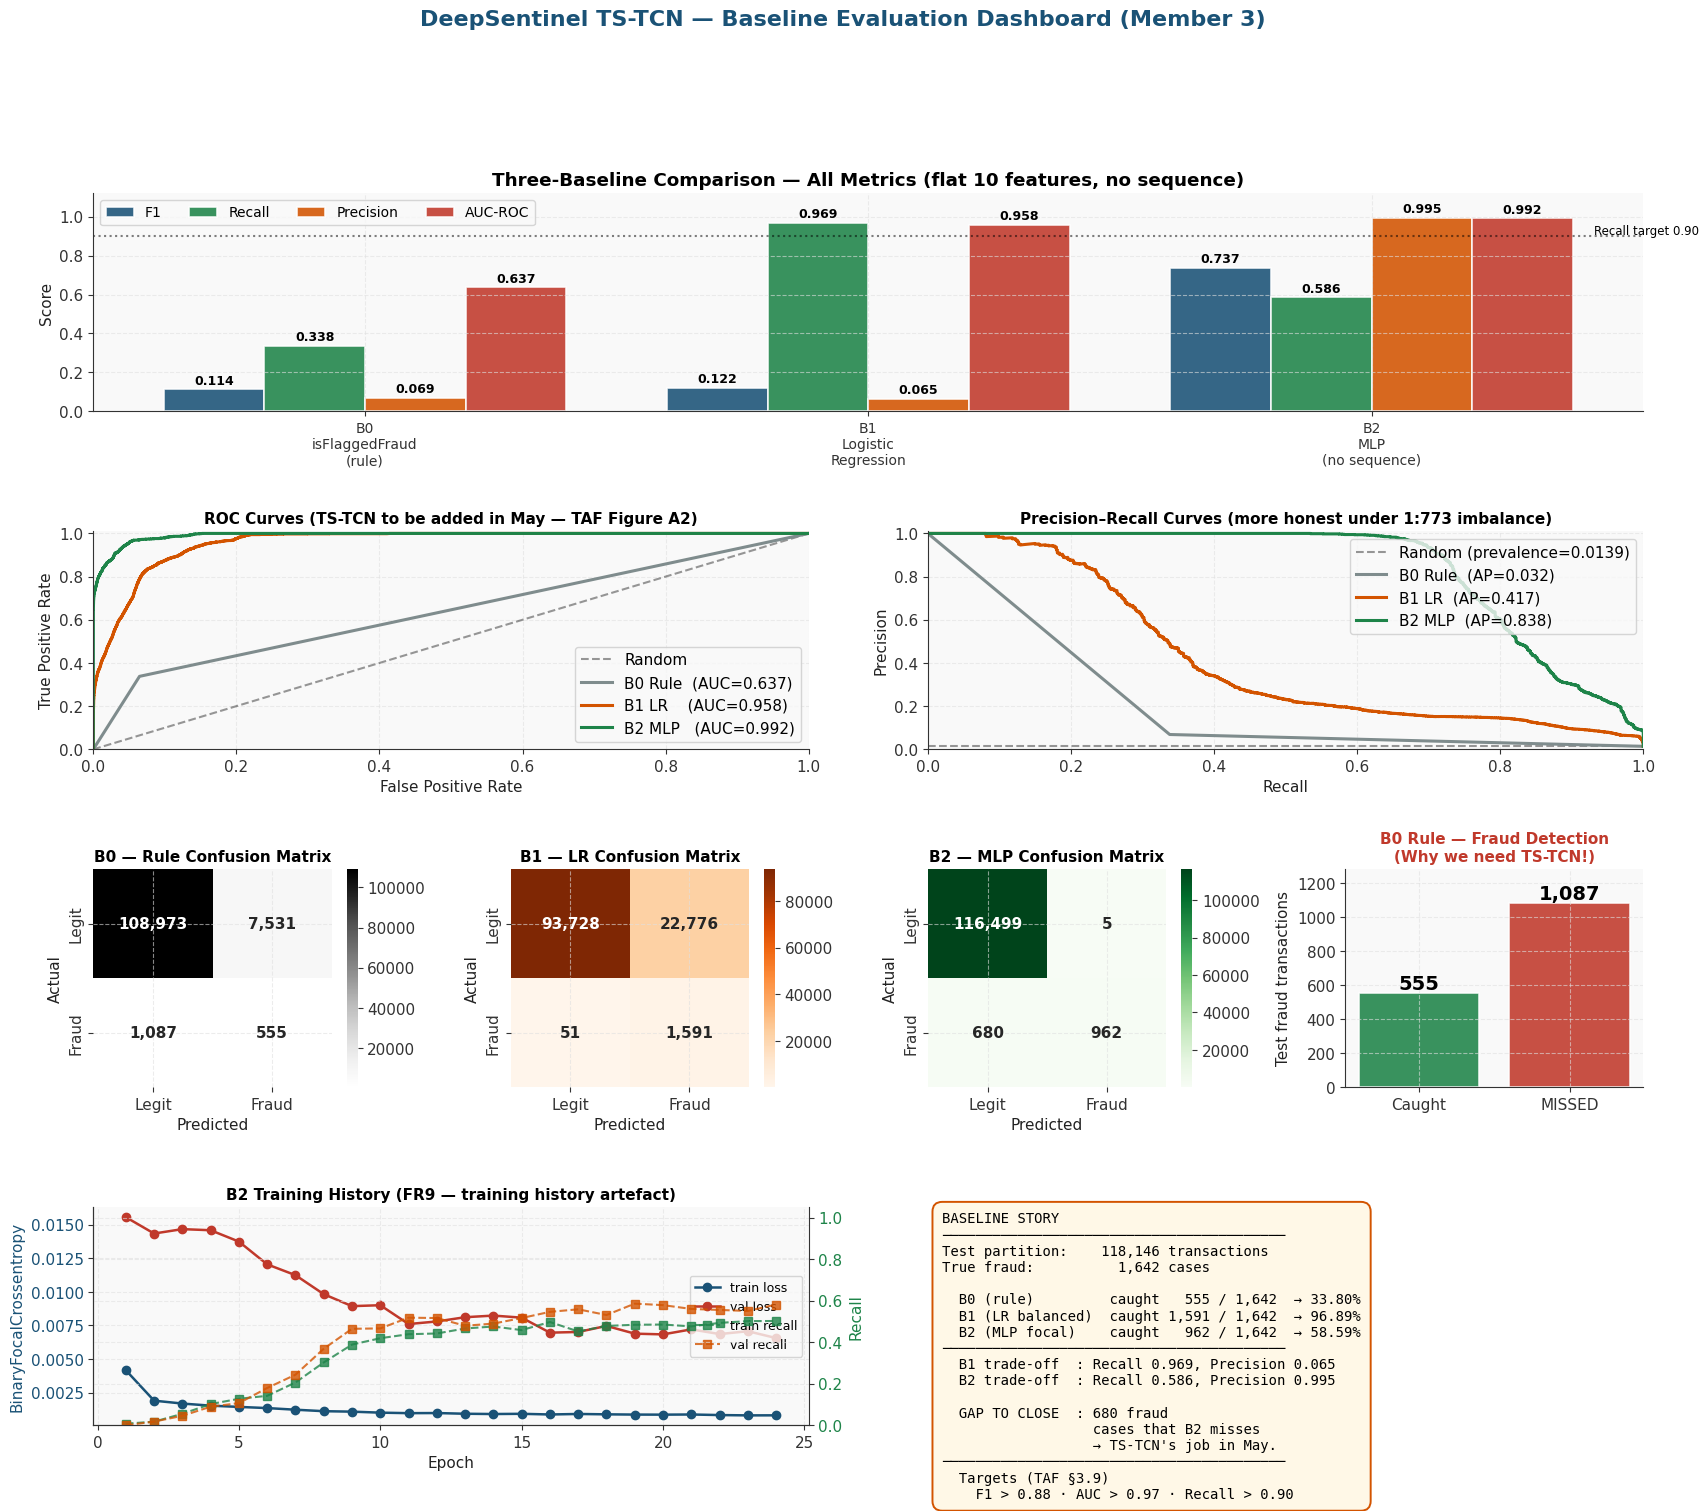

💾 Saved: outputs/03_baseline_dashboard.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 11 — Master Baseline Dashboard (8 panels)
# ═══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(4, 4, figure=fig, hspace=0.55, wspace=0.40)
fig.suptitle("DeepSentinel TS-TCN — Baseline Evaluation Dashboard (Member 3)",
             fontsize=16, fontweight="bold", color=DS_BLUE, y=0.995)

# Panel 1: Metric bars
ax1 = fig.add_subplot(gs[0, :])
labels = ["B0\nisFlaggedFraud\n(rule)", "B1\nLogistic\nRegression", "B2\nMLP\n(no sequence)"]
metric_grid = {
    "F1":        [b0_metrics["f1"],        b1_metrics["f1"],        b2_metrics["f1"]],
    "Recall":    [b0_metrics["recall"],    b1_metrics["recall"],    b2_metrics["recall"]],
    "Precision": [b0_metrics["precision"], b1_metrics["precision"], b2_metrics["precision"]],
    "AUC-ROC":   [b0_metrics["auc_roc"],   b1_metrics["auc_roc"],   b2_metrics["auc_roc"]],
}
metric_colors = [DS_BLUE, DS_GREEN, DS_ORANGE, DS_RED]
x = np.arange(3); w = 0.2
for i, (m, vals) in enumerate(metric_grid.items()):
    bars = ax1.bar(x + i*w, vals, w, label=m, color=metric_colors[i],
                   alpha=0.88, edgecolor="white", linewidth=1.2)
    for bar, v in zip(bars, vals):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
                 f"{v:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax1.axhline(0.90, color="black", linestyle=":", alpha=0.5)
ax1.text(2.95, 0.91, "Recall target 0.90", fontsize=8.5, ha="right")
ax1.set_xticks(x + 1.5*w); ax1.set_xticklabels(labels, fontsize=10)
ax1.set_ylim(0, 1.12); ax1.set_ylabel("Score")
ax1.set_title("Three-Baseline Comparison — All Metrics (flat 10 features, no sequence)",
              fontweight="bold")
ax1.legend(loc="upper left", ncol=4, fontsize=10)

# Panel 2: ROC
ax2 = fig.add_subplot(gs[1, 0:2])
ax2.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random")
roc_data = [
    (y_b0_prob, f"B0 Rule  (AUC={b0_metrics['auc_roc']:.3f})", DS_GREY),
    (y_b1_prob, f"B1 LR    (AUC={b1_metrics['auc_roc']:.3f})", DS_ORANGE),
    (y_b2_prob, f"B2 MLP   (AUC={b2_metrics['auc_roc']:.3f})", DS_GREEN),
]
for probs, lbl, col in roc_data:
    fpr, tpr, _ = roc_curve(y_test, probs)
    ax2.plot(fpr, tpr, label=lbl, linewidth=2.2, color=col)
ax2.set_xlabel("False Positive Rate"); ax2.set_ylabel("True Positive Rate")
ax2.set_title("ROC Curves (TS-TCN to be added in May — TAF Figure A2)",
              fontweight="bold", fontsize=11)
ax2.legend(loc="lower right"); ax2.set_xlim(0, 1); ax2.set_ylim(0, 1.01)

# Panel 3: PR curves
ax3 = fig.add_subplot(gs[1, 2:4])
prevalence = float(y_test.mean())
ax3.axhline(prevalence, color="black", linestyle="--", alpha=0.4,
            label=f"Random (prevalence={prevalence:.4f})")
for probs, lbl, col in roc_data:
    pr, rc, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    ax3.plot(rc, pr, label=f"{lbl.split('(')[0].strip()}  (AP={ap:.3f})",
             linewidth=2.2, color=col)
ax3.set_xlabel("Recall"); ax3.set_ylabel("Precision")
ax3.set_title("Precision–Recall Curves (more honest under 1:773 imbalance)",
              fontweight="bold", fontsize=11)
ax3.legend(loc="upper right"); ax3.set_xlim(0, 1); ax3.set_ylim(0, 1.01)

# Panels 4-6: Confusion matrices
def cm_panel(ax, y_true, y_pred, title, cmap):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt=",d", cmap=cmap,
                xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"],
                ax=ax, cbar=True, annot_kws={"fontsize": 11, "fontweight": "bold"})
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

cm_panel(fig.add_subplot(gs[2, 0]), y_test, y_b0_pred, "B0 — Rule Confusion Matrix", "Greys")
cm_panel(fig.add_subplot(gs[2, 1]), y_test, y_b1_pred, "B1 — LR Confusion Matrix",   "Oranges")
cm_panel(fig.add_subplot(gs[2, 2]), y_test, y_b2_pred, "B2 — MLP Confusion Matrix",  "Greens")

# Panel 7: B0 caught/missed
ax_b0 = fig.add_subplot(gs[2, 3])
caught = b0_metrics["true_positives"]
missed = b0_metrics["true_fraud_count"] - caught
bars = ax_b0.bar(["Caught", "MISSED"], [caught, missed],
                 color=[DS_GREEN, DS_RED], alpha=0.88, edgecolor="white", linewidth=1.2)
for bar, v in zip(bars, [caught, missed]):
    ax_b0.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(20, missed*0.02),
               f"{v:,}", ha="center", fontsize=14, fontweight="bold")
ax_b0.set_title("B0 Rule — Fraud Detection\n(Why we need TS-TCN!)",
                fontweight="bold", color=DS_RED, fontsize=11)
ax_b0.set_ylabel("Test fraud transactions")
ax_b0.set_ylim(0, missed * 1.18)

# Panel 8: training history
ax_h = fig.add_subplot(gs[3, 0:2])
ep = np.arange(1, len(hist_df) + 1)
ax_h.plot(ep, hist_df["loss"],     "o-", color=DS_BLUE,   label="train loss",   linewidth=1.8)
ax_h.plot(ep, hist_df["val_loss"], "o-", color=DS_RED,    label="val loss",     linewidth=1.8)
ax_h.set_xlabel("Epoch"); ax_h.set_ylabel("BinaryFocalCrossentropy", color=DS_BLUE)
ax_h.tick_params(axis="y", labelcolor=DS_BLUE)
ax_h.set_title("B2 Training History (FR9 — training history artefact)",
               fontweight="bold", fontsize=11)

ax_h2 = ax_h.twinx()
ax_h2.plot(ep, hist_df["recall"],     "s--", color=DS_GREEN,  label="train recall",  alpha=0.8)
ax_h2.plot(ep, hist_df["val_recall"], "s--", color=DS_ORANGE, label="val recall",    alpha=0.8)
ax_h2.set_ylabel("Recall", color=DS_GREEN)
ax_h2.tick_params(axis="y", labelcolor=DS_GREEN)
ax_h2.set_ylim(0, 1.05)
ax_h2.spines["right"].set_visible(True)

lines1, labels1 = ax_h.get_legend_handles_labels()
lines2, labels2 = ax_h2.get_legend_handles_labels()
ax_h.legend(lines1 + lines2, labels1 + labels2, loc="center right", fontsize=9)

# Panel 9: summary
ax_sum = fig.add_subplot(gs[3, 2:4])
ax_sum.axis("off")
caught_b1 = b1_metrics["true_positives"]; caught_b2 = b2_metrics["true_positives"]
caught_b0 = b0_metrics["true_positives"]
total_test_fraud = b0_metrics["true_fraud_count"]
text = (
    "BASELINE STORY\n"
    "─────────────────────────────────────────\n"
    f"Test partition:  {len(y_test):>9,} transactions\n"
    f"True fraud:      {total_test_fraud:>9,} cases\n\n"
    f"  B0 (rule)         caught {caught_b0:>5,} / {total_test_fraud:,}  → "
    f"{caught_b0/total_test_fraud*100:5.2f}%\n"
    f"  B1 (LR balanced)  caught {caught_b1:>5,} / {total_test_fraud:,}  → "
    f"{caught_b1/total_test_fraud*100:5.2f}%\n"
    f"  B2 (MLP focal)    caught {caught_b2:>5,} / {total_test_fraud:,}  → "
    f"{caught_b2/total_test_fraud*100:5.2f}%\n"
    "─────────────────────────────────────────\n"
    f"  B1 trade-off  : Recall {b1_metrics['recall']:.3f}, "
    f"Precision {b1_metrics['precision']:.3f}\n"
    f"  B2 trade-off  : Recall {b2_metrics['recall']:.3f}, "
    f"Precision {b2_metrics['precision']:.3f}\n\n"
    f"  GAP TO CLOSE  : {total_test_fraud - caught_b2:,} fraud\n"
    f"                  cases that B2 misses\n"
    f"                  → TS-TCN's job in May.\n"
    "─────────────────────────────────────────\n"
    "  Targets (TAF §3.9)\n"
    "    F1 > 0.88 · AUC > 0.97 · Recall > 0.90"
)
ax_sum.text(0.02, 0.98, text, transform=ax_sum.transAxes,
            fontsize=10, va="top", ha="left", family="monospace",
            bbox=dict(boxstyle="round,pad=0.7", facecolor="#FFF8E7",
                      edgecolor=DS_ORANGE, linewidth=1.4))

plt.savefig(OUT_DIR / "03_baseline_dashboard.png", dpi=160, bbox_inches="tight")
plt.show()
print(f"💾 Saved: {OUT_DIR}/03_baseline_dashboard.png")


## Cell 12 — Decision Summary

Final readable summary of decisions made and their justifications.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 12 — Decision Summary
# ═══════════════════════════════════════════════════════════════════════════════
print("=" * 78)
print(" DEEPSENTINEL TS-TCN — STAGE 1 & 2 DECISION SUMMARY")
print("=" * 78)
summary_text = f"""
[1] DATA SPLIT
    Strategy   : Time-based at step 595 (TAF §3.4)
    Train      : {len(train_df):>10,} rows (steps 1–595)
    Test       : {len(test_df):>10,} rows (steps 596–743)
    Test fraud : {int(y_test.sum()):>10,} cases (matches TAF §3.9)

[2] FEATURE ENGINEERING (FR1)
    F1–F10     : 10 universally-computable features (TAF Table 3)
    F6 weights : Derived from TRAIN partition only (no leakage)
    NaN/Inf    : 0 / 0

[3] BASELINE 0 — isFlaggedFraud Rule (TAF Table 3.3)
    Rule       : (type == TRANSFER) AND (amount > 200,000)
    F1={b0_metrics['f1']:.4f}  P={b0_metrics['precision']:.4f}  R={b0_metrics['recall']:.4f}  AUC={b0_metrics['auc_roc']:.4f}
    True positives: {b0_metrics['true_positives']} / {b0_metrics['true_fraud_count']}

[4] BASELINE 1 — Logistic Regression (TAF Table 3.3)
    solver=liblinear, max_iter=1000, class_weight=balanced
    F1={b1_metrics['f1']:.4f}  P={b1_metrics['precision']:.4f}  R={b1_metrics['recall']:.4f}  AUC={b1_metrics['auc_roc']:.4f}
    Trained in {b1_metrics['training_seconds']}s
    -> High Recall, low Precision: linear model failure mode (expected).

[5] BASELINE 2 — MLP (TAF Table 3.3)
    Dense(64,relu) -> Dropout(0.2) -> Dense(32,relu) -> Dropout(0.2) -> Dense(1,sigmoid)
    Loss: BinaryFocalCrossentropy(gamma=2.0)  <- Keras built-in (TAF EXACT)
    F1={b2_metrics['f1']:.4f}  P={b2_metrics['precision']:.4f}  R={b2_metrics['recall']:.4f}  AUC={b2_metrics['auc_roc']:.4f}
    Trained in {b2_metrics['training_seconds']}s over {b2_metrics['epochs_trained']} epochs.
    -> High Precision, plateaued Recall: non-linear model needs sequence context.

[6] EMPIRICAL JUSTIFICATION FOR TS-TCN
    The {b0_metrics['true_fraud_count'] - b2_metrics['true_positives']} fraud cases that B2 misses on test set
    define the empirical performance gap that the W=32 sequential
    context (TS-TCN) is designed to close.

    This validates the central claim of TAF section 3.6: that flat-feature
    models (linear or non-linear) cannot capture the fraud-clustering
    signal (mean 2.22 fraud predecessors in 32-window) that motivates
    the dilated causal TCN architecture.

[7] DELIVERABLES (Stage 1 & 2)
    [v] features.parquet                      -> Stage 3 (window builder)
    [v] outputs/scaler.pkl                    -> Stage 4 (TCN training)
    [v] outputs/y_test.npy                    -> Stage 6 (evaluation)
    [v] outputs/b0_probs.npy, b1_probs.npy, b2_probs.npy
    [v] outputs/lr_model.pkl, best_mlp.keras
    [v] outputs/baseline_metrics.json         (FR4)
    [v] outputs/four_model_comparison.csv     (FR10 partial)
    [v] outputs/type_risk_weights.json        (F6 reproducibility)
    [v] outputs/01_eda_overview.png
    [v] outputs/02_feature_distributions.png
    [v] outputs/03_baseline_dashboard.png

[8] FUNCTIONAL REQUIREMENT STATUS
    FR1  [v]  10 features computed, F6 train-only
    FR4  [v]  baseline_metrics.json saved before TCN training
    FR9  [.]  4 baseline visualisations done; fraud_attention heatmap & ablation chart pending
    FR10 [.]  Three baseline rows complete; TS-TCN row pending

[9] NEXT STEPS (per TAF Gantt)
    Apr W3-4 : T2 - tf.data window builder + ID buffer (deque maxlen=32)
    May W1-2 : T3 - Build 4-block dilated causal TCN + fraud_attention
    May W3-4 : T4 - Train TS-TCN (BinaryFocalCrossentropy gamma=2.0)
"""
print(summary_text)
print("=" * 78)


 DEEPSENTINEL TS-TCN — STAGE 1 & 2 DECISION SUMMARY

[1] DATA SPLIT
    Strategy   : Time-based at step 595 (TAF §3.4)
    Train      :  6,244,474 rows (steps 1–595)
    Test       :    118,146 rows (steps 596–743)
    Test fraud :      1,642 cases (matches TAF §3.9)

[2] FEATURE ENGINEERING (FR1)
    F1–F10     : 10 universally-computable features (TAF Table 3)
    F6 weights : Derived from TRAIN partition only (no leakage)
    NaN/Inf    : 0 / 0

[3] BASELINE 0 — isFlaggedFraud Rule (TAF Table 3.3)
    Rule       : (type == TRANSFER) AND (amount > 200,000)
    F1=0.1141  P=0.0686  R=0.3380  AUC=0.6367
    True positives: 555 / 1642

[4] BASELINE 1 — Logistic Regression (TAF Table 3.3)
    solver=liblinear, max_iter=1000, class_weight=balanced
    F1=0.1223  P=0.0653  R=0.9689  AUC=0.9583
    Trained in 44.76s
    -> High Recall, low Precision: linear model failure mode (expected).

[5] BASELINE 2 — MLP (TAF Table 3.3)
    Dense(64,relu) -> Dropout(0.2) -> Dense(32,relu) -> Dropout(0.

## Cell 13 — Backup Outputs to Google Drive

Copies the entire `outputs/` folder to a fixed Drive path so deliverables survive a Colab session reset.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 13 — Backup all outputs to Google Drive
# ═══════════════════════════════════════════════════════════════════════════════
DRIVE_DIR = Path("/content/drive/MyDrive/DeepSentinel/Member3_Baseline")
DRIVE_DIR.mkdir(parents=True, exist_ok=True)

backup_dir = DRIVE_DIR / "outputs"
if backup_dir.exists():
    shutil.rmtree(backup_dir)
shutil.copytree("outputs", backup_dir)

shutil.copy2("features.parquet", DRIVE_DIR / "features.parquet")

print(f"✅ Backup complete -> {DRIVE_DIR}")
print()
for p in sorted(DRIVE_DIR.rglob("*")):
    if p.is_file():
        size = p.stat().st_size
        size_str = f"{size/1024**2:6.1f} MB" if size > 1024**2 else f"{size/1024:6.1f} KB"
        print(f"   {size_str}  {p.relative_to(DRIVE_DIR)}")


✅ Backup complete -> /content/drive/MyDrive/DeepSentinel/Member3_Baseline

    376.0 MB  features.parquet
    376.6 KB  outputs/01_eda_overview.png
    351.2 KB  outputs/02_feature_distributions.png
    621.5 KB  outputs/03_baseline_dashboard.png
    461.6 KB  outputs/b0_probs.npy
    923.1 KB  outputs/b1_probs.npy
    461.6 KB  outputs/b2_probs.npy
      3.7 KB  outputs/b2_training_history.csv
      1.7 KB  outputs/baseline_metrics.json
     65.8 KB  outputs/best_mlp.keras
      0.4 KB  outputs/four_model_comparison.csv
      0.8 KB  outputs/lr_model.pkl
      0.7 KB  outputs/scaler.pkl
      0.1 KB  outputs/type_risk_weights.json
    461.6 KB  outputs/y_test.npy
